Идея A. Отрезать старые данные — то, что человек искал в январе, например, зимнюю резину, к апрелю ему уже не нужно. 
Идея B. Выкинуть показы — они создают 90% объема данных, но при этом сильно зашумлены, так как пользователь, например, мог просто быстро скроллить ленту.

Нам нужно выяснить три вещи:
- Воронку действий (eid): У нас анонимизированы типы событий (кроме контактов). Нам нужно по частоте угадать, где показы, где клики, где добавления в избранное.
- Плотность времени: Сколько реально событий было в январе, а сколько в апреле? Возможно, в январе данных и так мало.
- Холодный старт: Сколько действий в среднем совершает один юзер?

Предположение:
Показы (80-90% трафика) $\rightarrow$ Клики (3-10%) $\rightarrow$ Избранное (2-5%) $\rightarrow$ Контакты (1-2%).

In [ ]:
from pathlib import Path

import polars as pl

DATA_DIR = Path("../data/raw")
contact_df = pl.read_csv(DATA_DIR / "contact_eids.csv")
contact_eids = set(contact_df["mapped_eid"].to_list())

# Читаем 1 партицию (~1% трейна)
df = pl.read_parquet(DATA_DIR / "train_data" / "part_000.parquet")

# Группируем по типу события
eid_stats = (
    df.group_by("eid")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .with_columns(
        [
            (pl.col("count") / len(df) * 100).round(2).alias("percent"),
            pl.col("eid").is_in(list(contact_eids)).alias("is_contact"),
        ]
    )
)

display(eid_stats)

eid,count,percent,is_contact
u32,u32,f64,bool
7,45961480,88.93,false
10,3224942,6.24,false
4,600787,1.16,true
1,561094,1.09,false
15,283358,0.55,true
…,…,…,…
16,45394,0.09,true
2,7954,0.02,true
5,6471,0.01,true


Какой план по весам для ALS вырисовывается:
* eid = 7 (Показы) $\rightarrow$ Выкидываем полностью.
* eid = 10 и eid = 1 (Клики и микро-экшены) $\rightarrow$ Даем базовый вес 1.0.
* is_contact = True (Все 11 контактных событий) $\rightarrow$ Даем повышенный вес.

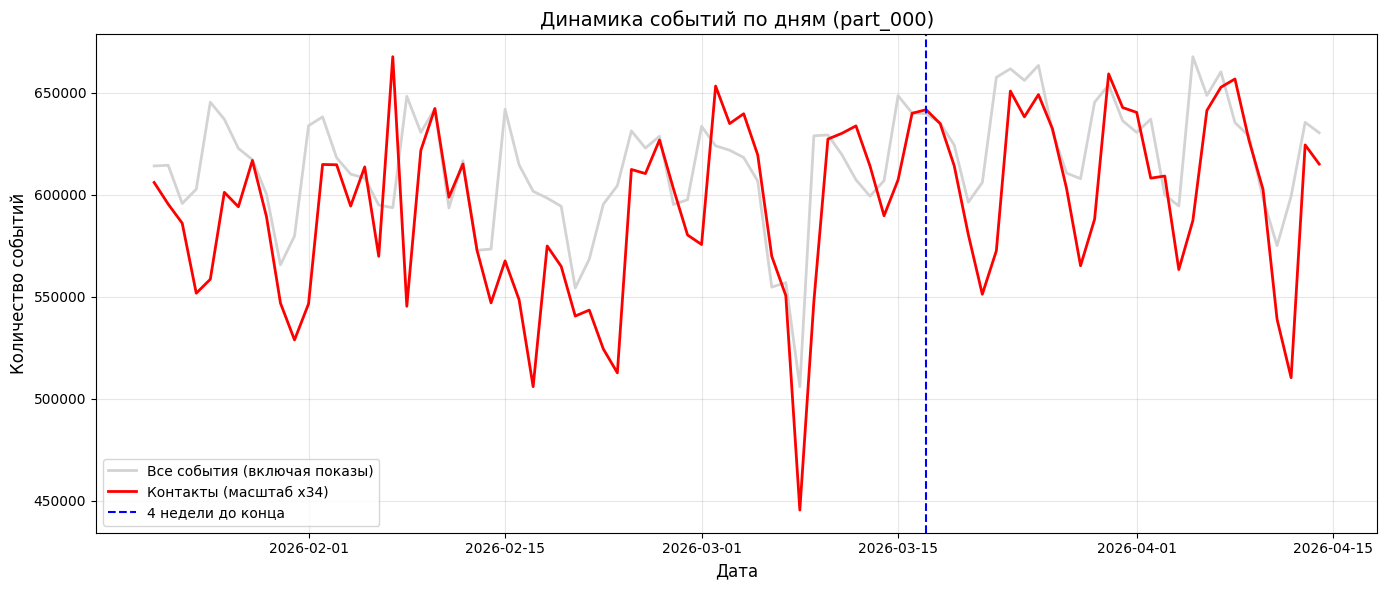

In [ ]:
import datetime

import matplotlib.pyplot as plt

# Оставляем в памяти только нужные колонки, чтобы было быстрее
time_df = df.select(["timestamp", "eid"]).with_columns(
    pl.from_epoch("timestamp", time_unit="ms").dt.date().alias("date")
)

daily_stats = (
    time_df.group_by("date")
    .agg(
        [
            pl.len().alias("total_events"),
            pl.col("eid").is_in(list(contact_eids)).sum().alias("contact_events"),
        ]
    )
    .sort("date")
)

plt.figure(figsize=(14, 6))

plt.plot(
    daily_stats["date"],
    daily_stats["total_events"],
    label="Все события (включая показы)",
    color="lightgray",
    linewidth=2,
)


scale_factor = daily_stats["total_events"].max() / daily_stats["contact_events"].max()
plt.plot(
    daily_stats["date"],
    daily_stats["contact_events"] * scale_factor,
    label=f"Контакты (масштаб x{scale_factor:.0f})",
    color="red",
    linewidth=2,
)

# Добавляем вертикальную линию за 4 недели до конца трейна (потенциальный срез)
cutoff_date = daily_stats["date"].max() - datetime.timedelta(days=28)
plt.axvline(x=cutoff_date, color="blue", linestyle="--", label="4 недели до конца")

plt.title("Динамика событий по дням (part_000)", fontsize=14)
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Количество событий", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

Всего уникальных пользователей в part_000: 82,570
Пользователей с полезной историей (>= 1 клик/контакт): 82,091
Абсолютно 'холодных' пользователей (только показы): 479 (0.6%)



p10,p25,Медиана,p75,p90,p99
f64,f64,f64,f64,f64,f64
3.0,7.0,24.0,70.0,167.0,675.0


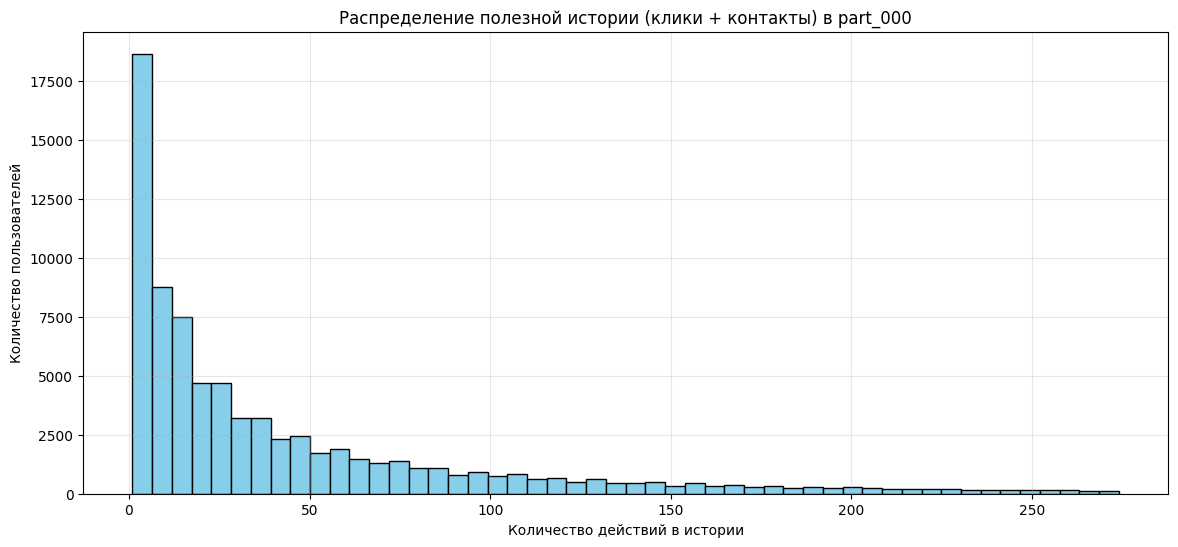

In [ ]:
df_clean = df.filter(pl.col("eid") != 7)

user_history_len = df_clean.group_by("user_id").agg(pl.len().alias("history_length"))

total_users = df["user_id"].n_unique()
users_with_history = len(user_history_len)
zero_history_users = total_users - users_with_history

print(f"Всего уникальных пользователей в part_000: {total_users:,}")
print(f"Пользователей с полезной историей (>= 1 клик/контакт): {users_with_history:,}")
print(
    f"Абсолютно 'холодных' пользователей (только показы): {zero_history_users:,} \
        ({(zero_history_users / total_users) * 100:.1f}%)\n"
)

percentiles = user_history_len.select(
    [
        pl.col("history_length").quantile(0.10).alias("p10"),
        pl.col("history_length").quantile(0.25).alias("p25"),
        pl.col("history_length").quantile(0.50).alias("Медиана"),
        pl.col("history_length").quantile(0.75).alias("p75"),
        pl.col("history_length").quantile(0.90).alias("p90"),
        pl.col("history_length").quantile(0.99).alias("p99"),
    ]
)

display(percentiles)

limit = user_history_len["history_length"].quantile(0.95)
hist_data = user_history_len.filter(pl.col("history_length") <= limit)["history_length"].to_list()

plt.figure(figsize=(14, 6))
plt.hist(hist_data, bins=50, color="skyblue", edgecolor="black")
plt.title("Распределение полезной истории (клики + контакты) в part_000")
plt.xlabel("Количество действий в истории")
plt.ylabel("Количество пользователей")
plt.grid(True, alpha=0.3)
plt.show()

* **Фильтрация шума**: Показы (eid = 7) составляют 89% логов, но несут слабый сигнал. Удаляем их полностью. Оставляем только взаимодействия (eid = 1, 10) и целевые контакты.
* **Срез по времени**: Интерес пользователей быстро устаревает, наблюдаются сильные календарные аномалии. Оставляем только последние 4 недели до даты отсечения.
* **Холодный старт**: Менее 0.6% пользователей не имеют истории кликов/контактов. Проблема холодного старта минимальна, базовая эвристика понадобится лишь для единиц.
* **Борьба с выбросами**: Топ-1% пользователей генерируют сотни действий (боты/перекупы). Чтобы они не искажали веса градиентов в ALS, вводим лимит на 100-150 самых свежих действий для каждого пользователя.